# 1. MaskClustering Output Exploration

In [1]:
import numpy as np
from PIL import Image
import os
import torch
import matplotlib.pyplot as plt
import images_processing as img_process
import caption_generator as cap
# pip install torch==2.4.0 transformers==4.46.2 numpy==1.25.0 pillow==10.3.0
# pip install flash-attn==2.7.0.post2 --no-build-isolation
# pip install transformers accelerate sentencepiece

In [2]:
output_path = 'data/demo/scene0608_00/output/object/demo/object_dict.npy'
output = np.load(output_path, allow_pickle=True)

In [31]:
data = output.item()
object_0 = data[28]
for k, v in object_0.items():
    # the structure is frame_id, mask_id, score
    print(f'{k}: {v}')

point_ids: [49184 49185 49186 ... 49149 49150 49151]
mask_list: [(490, 8, 0.5926014893105933), (470, 5, 0.5829930338698054), (340, 11, 0.5700216190247418), (350, 12, 0.5601729521979342), (330, 12, 0.527744415085275), (360, 6, 0.5202978621186645), (420, 7, 0.5128513091520538), (400, 9, 0.49867883737689167), (500, 5, 0.4921931299543598), (480, 6, 0.47513812154696133), (540, 7, 0.4679317799663704), (410, 5, 0.4508767715589719), (530, 4, 0.4410281047321643), (510, 7, 0.43790535671390823), (520, 7, 0.4196492913764112), (280, 12, 0.4054768196012491), (430, 12, 0.40259428296901273), (370, 6, 0.3884218111938506), (390, 7, 0.3879413884218112), (270, 13, 0.3877011770357915), (320, 5, 0.3692049003122748), (380, 6, 0.3564736968532308), (450, 6, 0.35335094883497475), (290, 12, 0.3473456641844823), (260, 18, 0.33629594042757627), (440, 9, 0.3151573384578429), (300, 13, 0.29570021619024744), (250, 21, 0.2423732884938746), (460, 6, 0.2423732884938746), (580, 2, 0.23901032908959885), (590, 3, 0.2200336

In [32]:
frame_ids = [frame for (frame, mask, score) in object_0['repre_mask_list']]
mask_ids = [mask for (frame, mask, score) in object_0['repre_mask_list']]
for frame, mask in zip(frame_ids, mask_ids):
    print(f'Frame {frame} -> Mask {mask}')

Frame 490 -> Mask 8
Frame 470 -> Mask 5
Frame 340 -> Mask 11
Frame 350 -> Mask 12
Frame 330 -> Mask 12


In [33]:
image_path = 'data/demo/scene0608_00/color_640'
images = [Image.open(f'{image_path}/{id}.jpg') for id in frame_ids]

mask_path = 'data/demo/scene0608_00/output/mask'
masks = [
    Image.open(os.path.join(mask_path, f'{img}.png')).convert('L')
    for img in frame_ids
]

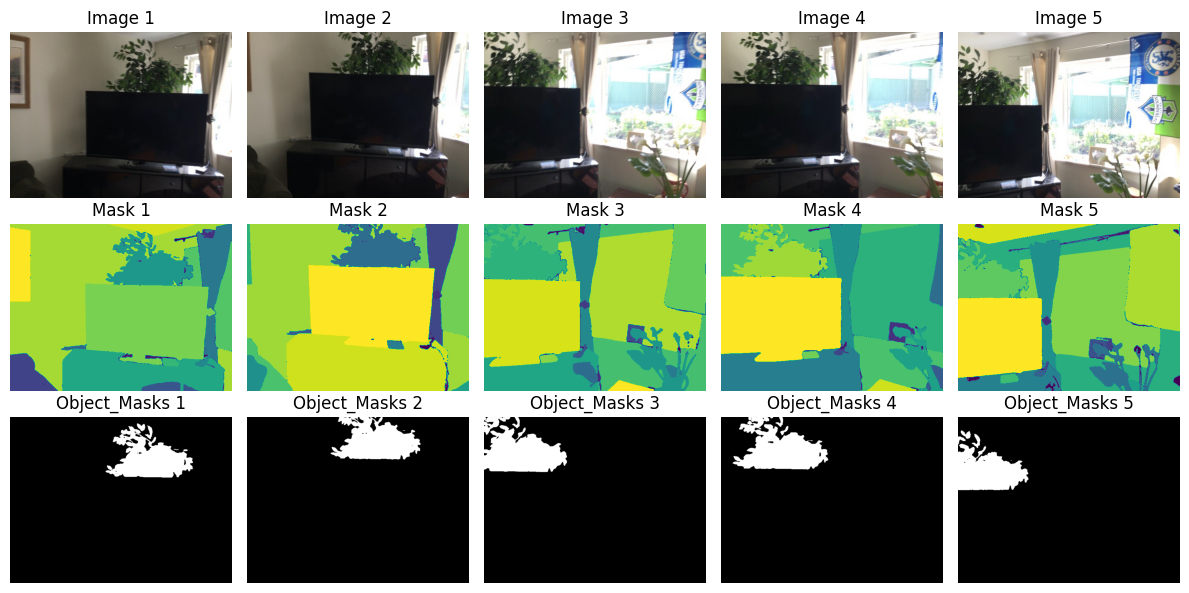

In [34]:
img_process.img_visualization(images=images, masks=masks, mask_ids=mask_ids)

# 2. Bounding Boxes of Objects

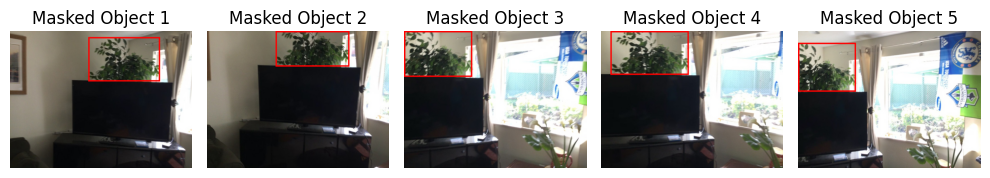

In [35]:
masked_images = []
for img, id, mask in zip(images, mask_ids, masks):
    binary_mask = (np.array(mask) == id).astype(np.uint8) * 255
    x_min, y_min, x_max, y_max = img_process.mask_to_bbox(binary_mask)
    bbox = (x_min, y_min, x_max, y_max)
    if len(masked_images) <= 5:
        masked_images.append(img_process.draw_bbox_on_image(img, bbox))
img_process.img_visualization(masked_images=masked_images)

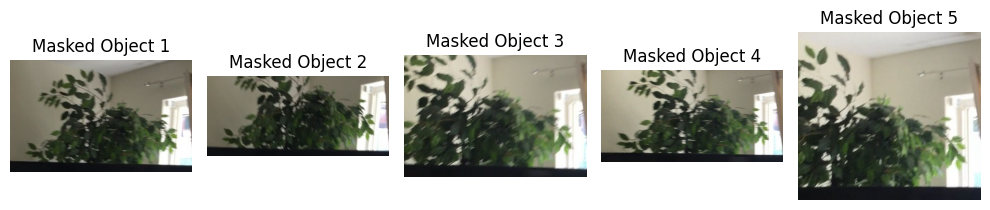

In [36]:
masked_images_padded = []
for img, id, mask in zip(images, mask_ids, masks):
    binary_mask = (np.array(mask) == id).astype(np.uint8) * 255
    x_min, y_min, x_max, y_max = img_process.mask_to_bbox(binary_mask)
    bbox = (x_min, y_min, x_max, y_max)
    cropped_img = img_process.crop_with_padding(img, bbox, padding_ratio=0.1)
    if len(masked_images_padded) < 5:
        masked_images_padded.append(cropped_img)
img_process.img_visualization(masked_images=masked_images_padded)

# Object Level Captioning

In [37]:
caption_generator = cap.Caption_Generator()

Device set to use cuda:0


In [38]:
images = masked_images
max_partition = 5
text = '''
You are provided with multiple views of a single object and the views are cropped to only showcase the object.

Your task is to write **one short paragraph** describing only the main object.

Focus on the object's physical appearance, attributes or properties. Do not mention background, surrounding objects, or the object's spatial position and the red bounding boxes.

Now generate the object caption for the following object:
'''
query = '\n'.join([f'Image {i+1}: <image>' for i in range(len(images))]) + '\n' + text
obj_caption, obj_caption_summarized = caption_generator.single_object_image_processing_object_captioning(data = data, obj_id=28)

The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


In [39]:
print(obj_caption)
print(obj_caption_summarized)

The image features a large green plant with broad leaves, positioned in an indoor setting. The plant is the main subject, occupying the majority of the frame. The lighting is natural, likely from a nearby window, casting soft shadows and highlighting the texture of the leaves. The plant's leaves are dense and healthy, suggesting it is well-cared for. The background is minimal, with a plain wall and a window that allows light to enter, creating a serene and natural atmosphere. The image captures the plant in a moment of tranquility, with no other objects or distractions in the frame.
The image features a large green plant with broad leaves, located in an indoor setting. The plant is the main subject, occupying the majority of the frame. The lighting is natural, likely from a nearby window, casting soft shadows and highlighting the texture of the leaves. The plant's leaves are dense and healthy, suggesting it is well cared for. The background is minimal, with a plain wall and a window th

In [11]:
output_1 = caption_generator.object_level_caption(query, masked_images, max_partition)
print(output_1)
output_2 = caption_generator.object_level_caption(query, masked_images_padded, max_partition)
print(output_2)

The main object in the image, highlighted by the red bounding box, is a chessboard. It is a standard chessboard with alternating black and white squares, placed on a glass coffee table. The chessboard is positioned in the lower left corner of the image, with a chess set and a booklet partially visible underneath it. The chessboard's design is classic, with a checkered pattern, and it appears to be in good condition. The surrounding area includes a couch with cushions, a TV stand, and a carpeted floor, contributing to the setting of a living room.
The main object in the image is a chessboard, characterized by its black and white checkered pattern. The chessboard is the central focus of the image, with the Vizio brand prominently displayed on a booklet or pamphlet held in the foreground. The chessboard's design is traditional, with alternating squares of light and dark colors, and the Vizio branding suggests it is a product of the Vizio brand. The image captures the chessboard in a dimly

# Object-Level Caption for all Objects

In [12]:
caption_generator.image_processing_object_captioning(data=data)

Generating Object Level Captions::   6%|▋         | 9/144 [00:20<05:13,  2.32s/it]You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Generating Object Level Captions:: 100%|██████████| 144/144 [04:47<00:00,  2.00s/it]


In [13]:
data[0]['object_level_caption_summarized']

'A guitar, located on the floor to the right of a wooden chest with a gold emboss cover, and a green glass vase containing a single stem of flowers.'

# Object-Surrounding Caption

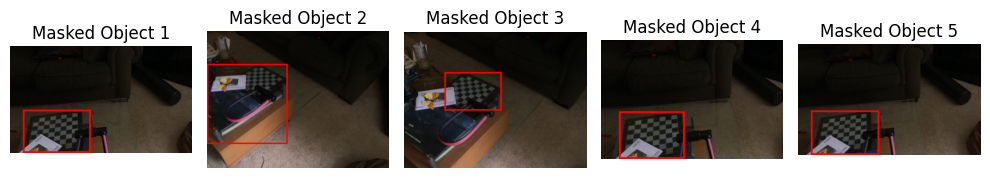

This object is a chessboard, a standard game piece used in the game of chess. It is positioned on a glass coffee table, which is part of a living room setting. The chessboard is placed on a black and white checkered surface, with a pink handle and a black grip visible. The chessboard is surrounded by a red bounding box, indicating its importance in the scene. The surrounding area includes a dark-colored couch, a glass coffee table, and a carpeted floor, suggesting a typical living room environment. The chessboard is a central element, with other objects like a book and a pen nearby, indicating a space used for leisure and possibly gaming.


In [14]:
print(caption_generator.single_image_processing_surrounding_captioning(data = data, obj_id=40))

In [15]:
caption_generator.image_processing_surrounding_captioning(data = data)

Generating Object Surrounding Captions:: 100%|██████████| 144/144 [04:24<00:00,  1.84s/it]


In [16]:
data[0].keys()

dict_keys(['point_ids', 'mask_list', 'repre_mask_list', 'object_level_caption', 'object_level_caption_summarized', 'object_surrounding_caption'])

In [17]:
data[0]['object_surrounding_caption']

'This object is a large, dark-colored book with gold lettering, placed on a table. It is positioned next to a guitar, which is leaning against a chair. The book is surrounded by a green vase with a plant, and a pen is placed on top of it. The setting appears to be a personal living space, possibly a bedroom or a study, with a window in the background letting in natural light. The book and guitar are the main objects in the foreground, with the book slightly to the left and the guitar to the right. The surrounding area includes a bean bag on the floor and a small plant in the background, contributing to a cozy and lived-in atmosphere.'

In [23]:
obj_0 = data[0]
for k, v in obj_0.items():
    print(f'{k}: {v}')

point_ids: [90113 90114 81928 ... 90065 90066 90079]
mask_list: [(3270, 19, 0.5975049244911359), (3260, 17, 0.587655942219304), (3250, 13, 0.5745239658568615), (3360, 9, 0.525279054497702), (120, 3, 0.510505581089954), (130, 15, 0.49967170059093896), (2150, 23, 0.49868680236375573), (70, 5, 0.47209455022980956), (90, 4, 0.4665134602757715), (140, 7, 0.4576493762311228), (2160, 11, 0.45075508864084046), (2180, 6, 0.44977019041365723), (2200, 20, 0.4474720945502298), (3220, 14, 0.4409061063690085), (160, 7, 0.42974392646093235), (80, 6, 0.41365725541694026), (3310, 3, 0.4024950755088641), (3370, 26, 0.38673670387393305), (3310, 1, 0.3624425476034143), (220, 23, 0.3621142481943532), (3340, 8, 0.345370978332239), (3320, 8, 0.345370978332239), (2220, 21, 0.3417596848325673), (3340, 5, 0.3217334208798424), (100, 16, 0.3079448456992777), (110, 11, 0.2964543663821405), (230, 15, 0.2948128693368352), (210, 24, 0.29415627051871307), (40, 15, 0.2931713722915299), (2330, 12, 0.28003939592908733), 